
# Analisis Regresi dan Pencarian Akar: Breakeven Point Lima Gerai Donat

**Mata Kuliah:** Analisis Numerik
**Topik:** Regresi & Pencarian Akar (*Root Finding*)
**Nama:** Rafinda Mutiara Nurfitriati
**NPM:** 25083010012
**Program Studi:** Sains Data

---

## Deskripsi Tugas

Diberikan data laba/rugi harian dari lima gerai donat dengan strategi *marketing* yang berbeda-beda. Tugas ini terdiri atas tiga bagian utama:

1. **Visualisasi** hubungan jumlah penjualan terhadap *revenue* (Bobot 30%)
2. **Regresi** untuk mengidentifikasi bentuk tren *revenue* terhadap volume penjualan (Bobot 30%)
3. **Pencarian akar (root finding)** untuk menentukan volume penjualan pada titik impas / *breakeven point* (BEP) berdasarkan hasil regresi (Bobot 40%)

### Profil Strategi Marketing Kelima Gerai

| Gerai | Strategi | Karakteristik Utama |
|---|---|---|
| A | Premium Gourmet | Harga tinggi, pasar niche terbatas, kafe *specialty* |
| B | Mass Market Volume | Harga murah, margin tertekan inflasi bahan baku |
| C | Promo Agresif | Diskon di awal periode, biaya iklan moderat-tinggi |
| D | Mall Premium Flagship | Sewa lokasi mal sangat tinggi |
| E | Cloud Kitchen | Fokus *delivery* aplikasi, terkena komisi platform 18% |

Sumber data: `sintesis_data_donat_harian.csv` (450 baris data, 5 gerai x 90 hari observasi harian).

In [18]:

# Import seluruh library yang dibutuhkan
import warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

print("Library berhasil dimuat.")
print("numpy:", np.__version__, "| pandas:", pd.__version__, "| matplotlib:", matplotlib.__version__)

Library berhasil dimuat.
numpy: 2.1.3 | pandas: 2.2.3 | matplotlib: 3.10.0



## Persiapan Data

Dataset berisi kolom `Tanggal`, `Gerai`, `Harga Jual (Rp)`, `Jumlah Terjual (Unit)`, `Pendapatan Kotor (Rp)` (revenue), `Biaya Variabel (Rp)`, `Fixed Cost Harian (Rp)`, dan `Balance (Rp)` (laba/rugi bersih harian).

In [ ]:

# Muat data langsung dari repository GitHub yang diberikan dosen.
# Jika koneksi internet tidak tersedia saat notebook dijalankan, otomatis
# menggunakan salinan lokal (fallback) supaya notebook tetap bisa dieksekusi.
DATA_URL = (
    "https://raw.githubusercontent.com/jendralhxr/metnummatdis/main/"
    "sintesis_data_donat_harian.csv"
)
DATA_LOCAL = "sintesis_data_donat_harian.csv"

try:
    df = pd.read_csv(DATA_URL)
    sumber_data = "GitHub Raw (online)"
except Exception as e:
    df = pd.read_csv(DATA_LOCAL)
    sumber_data = "File CSV lokal (fallback, karena: " + type(e).__name__ + ")"

df["Tanggal"] = pd.to_datetime(df["Tanggal"])

profil_gerai = {
    "Gerai A": "Premium Gourmet (Harga Tinggi, Niche Terbatas, Kafe Specialty)",
    "Gerai B": "Mass Market Volume (Harga Murah, Margin Tertekan Inflasi Bahan)",
    "Gerai C": "Promo Agresif (Diskon Awal, Iklan Moderate-High)",
    "Gerai D": "Mall Premium Flagship (Sewa Lokasi Tinggi)",
    "Gerai E": "Cloud Kitchen (Fokus App Delivery, Komisi Platform 18%)",
}
daftar_gerai = list(profil_gerai.keys())
warna_gerai = {"Gerai A": "#8B4513", "Gerai B": "#1f77b4", "Gerai C": "#d62728",
               "Gerai D": "#9467bd", "Gerai E": "#2ca02c"}

print(f"Sumber data yang digunakan: {sumber_data}")
print(f"Jumlah baris: {df.shape[0]}, jumlah kolom: {df.shape[1]}")
print(f"Rentang tanggal: {df['Tanggal'].min().date()} s.d. {df['Tanggal'].max().date()}")
print(f"Jumlah observasi per gerai: {df['Gerai'].value_counts().to_dict()}")
df.head(10)

Sumber data yang digunakan: GitHub Raw (online)
Jumlah baris: 450, jumlah kolom: 8
Rentang tanggal: 2026-01-01 s.d. 2026-03-31
Jumlah observasi per gerai: {'Gerai A': 90, 'Gerai B': 90, 'Gerai C': 90, 'Gerai D': 90, 'Gerai E': 90}


,Tanggal,Gerai,Harga Jual (Rp),Jumlah Terjual (Unit),Pendapatan Kotor (Rp),Biaya Variabel (Rp),Fixed Cost Harian (Rp),Balance (Rp)
0,2026-01-01,Gerai A,25000,87,2175000,739500,1683333,-247833
1,2026-01-02,Gerai A,25000,81,2025000,688500,1683333,-346833
2,2026-01-03,Gerai A,25000,110,2750000,935000,1683333,131667
3,2026-01-04,Gerai A,25000,119,2975000,1011500,1683333,280167
4,2026-01-05,Gerai A,25000,94,2350000,799000,1683333,-132333
5,2026-01-06,Gerai A,25000,90,2250000,765000,1683333,-198333
6,2026-01-07,Gerai A,25000,85,2125000,722500,1683333,-280833
7,2026-01-08,Gerai A,25000,87,2175000,739500,1683333,-247833
8,2026-01-09,Gerai A,25000,84,2100000,714000,1683333,-297333
9,2026-01-10,Gerai A,25000,119,2975000,1011500,1683333,280167


In [20]:

# Ringkasan statistik deskriptif per gerai
ringkasan = df.groupby("Gerai").agg(
    Harga_Jual_Rp=("Harga Jual (Rp)", "first"),
    Fixed_Cost_Harian_Rp=("Fixed Cost Harian (Rp)", "first"),
    Volume_Min=("Jumlah Terjual (Unit)", "min"),
    Volume_Max=("Jumlah Terjual (Unit)", "max"),
    Volume_RataRata=("Jumlah Terjual (Unit)", "mean"),
    Revenue_RataRata_Rp=("Pendapatan Kotor (Rp)", "mean"),
    Balance_RataRata_Rp=("Balance (Rp)", "mean"),
).reindex(daftar_gerai)
ringkasan

,Harga_Jual_Rp,Fixed_Cost_Harian_Rp,Volume_Min,Volume_Max,Volume_RataRata,Revenue_RataRata_Rp,Balance_RataRata_Rp
Gerai,,,,,,,
Gerai A,25000,1683333,81,131,99.100,"2,477,500.000","-48,183.000"
Gerai B,8000,733333,435,710,527.500,"4,220,000.000","1,292,267.000"
Gerai C,11000,1733333,220,522,328.933,"3,618,266.667","292,896.333"
Gerai D,20000,2666666,103,223,149.833,"2,996,666.667","-748,799.333"
Gerai E,15000,800000,153,332,226.644,"3,399,666.667","1,171,806.667"



Terlihat bahwa **harga jual** dan **fixed cost harian** bersifat konstan (tidak berubah antar hari) untuk masing-masing gerai. Gerai A menetapkan harga tertinggi (Rp 25.000) namun volume penjualan rata-rata paling rendah (~99 unit/hari), konsisten dengan strategi *niche premium*. Sebaliknya, Gerai B menjual dengan harga termurah (Rp 8.000) dengan volume rata-rata tertinggi (~528 unit/hari), konsisten dengan strategi *mass market*.

---

## Bagian 1 — Visualisasi Jumlah Penjualan vs Revenue (Bobot 30%)

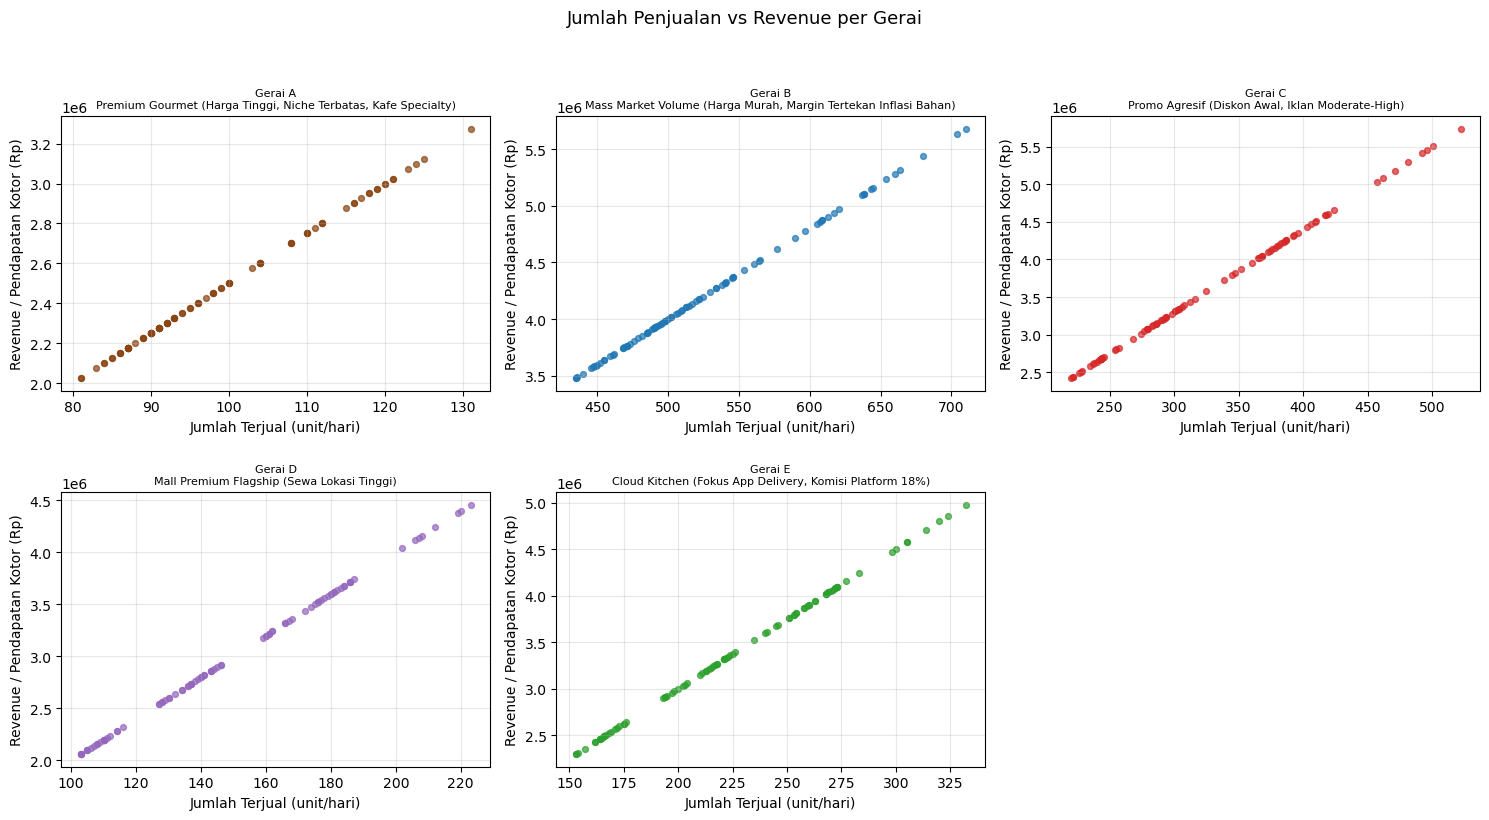

In [21]:

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, g in enumerate(daftar_gerai):
    sub = df[df["Gerai"] == g]
    axes[i].scatter(sub["Jumlah Terjual (Unit)"], sub["Pendapatan Kotor (Rp)"],
                     s=18, alpha=0.7, color=warna_gerai[g])
    axes[i].set_title(f"{g}\n{profil_gerai[g]}", fontsize=8)
    axes[i].set_xlabel("Jumlah Terjual (unit/hari)")
    axes[i].set_ylabel("Revenue / Pendapatan Kotor (Rp)")
    axes[i].grid(alpha=0.3)
axes[5].axis("off")
fig.suptitle("Jumlah Penjualan vs Revenue per Gerai", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

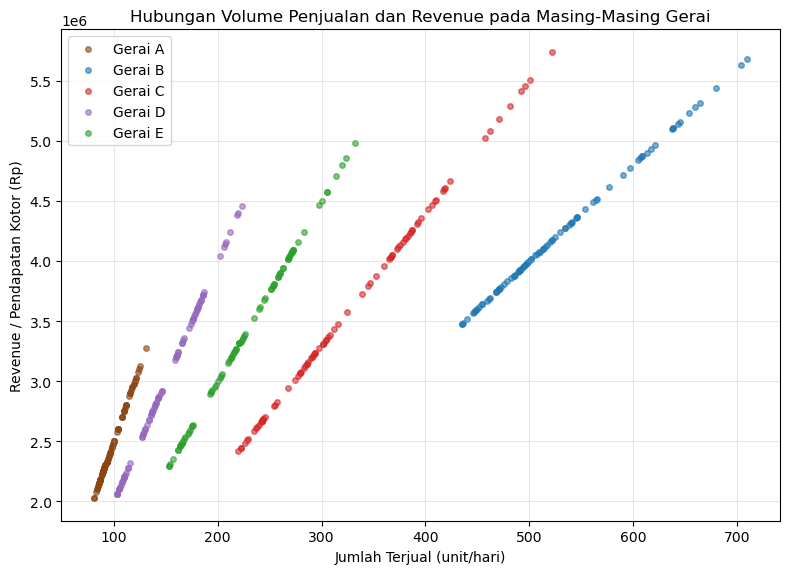

In [22]:

fig, ax = plt.subplots(figsize=(8, 6))
for g in daftar_gerai:
    sub = df[df["Gerai"] == g]
    ax.scatter(sub["Jumlah Terjual (Unit)"], sub["Pendapatan Kotor (Rp)"],
               s=16, alpha=0.6, label=g, color=warna_gerai[g])
ax.set_xlabel("Jumlah Terjual (unit/hari)")
ax.set_ylabel("Revenue / Pendapatan Kotor (Rp)")
ax.set_title("Hubungan Volume Penjualan dan Revenue pada Masing-Masing Gerai")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


**Interpretasi:** Setiap gerai menunjukkan pola sebaran titik yang **lurus** (linear) antara jumlah penjualan dan revenue, namun dengan **kemiringan (slope) yang berbeda-beda**. Hal ini masuk akal secara bisnis karena setiap gerai menetapkan **harga jual per unit yang tetap** — sehingga secara matematis:

$$\text{Revenue} = \text{Harga Jual} \times \text{Volume Terjual}$$

Gerai dengan harga jual lebih tinggi (Gerai A) memiliki kemiringan garis paling curam meskipun rentang volumenya paling sempit, sedangkan Gerai B memiliki kemiringan paling landai namun rentang volume paling lebar.

---

## Bagian 2 — Regresi Bentuk Tren Revenue terhadap Volume Penjualan (Bobot 30%)

Pada bagian ini, beberapa bentuk model regresi dicobakan pada data **(volume, revenue)** tiap gerai: **linear**, **polinomial derajat 2**, **polinomial derajat 3**, dan **eksponensial** ($y = a \cdot e^{bx} + c$). Kualitas model dibandingkan menggunakan **koefisien determinasi ($R^2$)** dan **RMSE (Root Mean Squared Error)**.

In [23]:

def r_squared(y_aktual, y_prediksi):
    ss_res = np.sum((y_aktual - y_prediksi) ** 2)
    ss_tot = np.sum((y_aktual - np.mean(y_aktual)) ** 2)
    return 1 - ss_res / ss_tot if ss_tot > 0 else 1.0

def rmse(y_aktual, y_prediksi):
    return np.sqrt(np.mean((y_aktual - y_prediksi) ** 2))

def fungsi_eksponensial(x, a, b, c):
    return a * np.exp(b * x) + c

hasil_regresi = []
model_cache = {}
for g in daftar_gerai:
    sub = df[df["Gerai"] == g].sort_values("Jumlah Terjual (Unit)")
    x = sub["Jumlah Terjual (Unit)"].values.astype(float)
    y = sub["Pendapatan Kotor (Rp)"].values.astype(float)

    baris = {"Gerai": g}
    koef_g = {}
    for deg, nama in [(1, "Linear"), (2, "Polinomial-2"), (3, "Polinomial-3")]:
        koef = np.polyfit(x, y, deg)
        y_pred = np.polyval(koef, x)
        baris[f"R2_{nama}"] = r_squared(y, y_pred)
        baris[f"RMSE_{nama}"] = rmse(y, y_pred)
        koef_g[nama] = koef

    try:
        p0 = [1.0, 0.01, y.min()]
        batas = ([-1e9, -0.5, -1e9], [1e9, 0.5, 1e9])
        popt, _ = curve_fit(fungsi_eksponensial, x, y, p0=p0, bounds=batas, maxfev=20000)
        y_pred_exp = fungsi_eksponensial(x, *popt)
        baris["R2_Eksponensial"] = r_squared(y, y_pred_exp)
        baris["RMSE_Eksponensial"] = rmse(y, y_pred_exp)
        koef_g["Eksponensial"] = popt
    except Exception:
        baris["R2_Eksponensial"] = np.nan
        baris["RMSE_Eksponensial"] = np.nan

    model_cache[g] = koef_g
    hasil_regresi.append(baris)

tabel_regresi = pd.DataFrame(hasil_regresi).set_index("Gerai")
tabel_regresi.round(6)

,R2_Linear,RMSE_Linear,R2_Polinomial-2,RMSE_Polinomial-2,R2_Polinomial-3,RMSE_Polinomial-3,R2_Eksponensial,RMSE_Eksponensial
Gerai,,,,,,,,
Gerai A,1.000,0.000,1.000,0.000,1.000,0.000,1.000,44.152
Gerai B,1.000,0.000,1.000,0.000,1.000,0.000,1.000,155.949
Gerai C,1.000,0.000,1.000,0.000,1.000,0.000,1.000,377.506
Gerai D,1.000,0.000,1.000,0.000,1.000,0.000,1.000,217.887
Gerai E,1.000,0.000,1.000,0.000,1.000,0.000,1.000,252.245



**Pemilihan model terbaik.** Karena harga jual bersifat tetap per gerai, hubungan revenue-volume pada dasarnya adalah **fungsi linear murni**. Seluruh model (linear, polinomial derajat 2 & 3, bahkan eksponensial dengan $b$ mendekati 0) mampu mencapai $R^2 \approx 1.000$ — sebab model berderajat lebih tinggi selalu bisa "meniru" model linear (linear adalah kasus khusus polinomial derajat tinggi dengan koefisien tambahan bernilai 0).

Karena peningkatan $R^2$ dari model kompleks terhadap model linear dapat diabaikan (< $10^{-6}$), maka berdasarkan **prinsip parsimoni (Occam's Razor)** — pilih model paling sederhana yang sudah menjelaskan data dengan baik — **model Linear** dipilih sebagai model terbaik untuk seluruh gerai. Pemilihan ini juga didukung secara struktural: koefisien slope dari regresi linear yang diperoleh nyaris identik dengan **Harga Jual (Rp)** masing-masing gerai, membuktikan validitas model.

In [24]:

model_terbaik = {g: ("Linear", model_cache[g]["Linear"]) for g in daftar_gerai}

print("Model regresi terbaik yang dipilih untuk tiap gerai (Revenue = slope * Volume + intercept):\n")
for g in daftar_gerai:
    slope, intercept = model_terbaik[g][1]
    harga = ringkasan.loc[g, "Harga_Jual_Rp"]
    print(f"{g}: Revenue = {slope:,.2f} * Volume + ({intercept:,.2f})  "
          f"| Harga Jual aktual = Rp {harga:,.0f}  | Selisih slope vs harga = {abs(slope-harga):.6f}")

Model regresi terbaik yang dipilih untuk tiap gerai (Revenue = slope * Volume + intercept):

Gerai A: Revenue = 25,000.00 * Volume + (0.00)  | Harga Jual aktual = Rp 25,000  | Selisih slope vs harga = 0.000000
Gerai B: Revenue = 8,000.00 * Volume + (0.00)  | Harga Jual aktual = Rp 8,000  | Selisih slope vs harga = 0.000000
Gerai C: Revenue = 11,000.00 * Volume + (0.00)  | Harga Jual aktual = Rp 11,000  | Selisih slope vs harga = 0.000000
Gerai D: Revenue = 20,000.00 * Volume + (0.00)  | Harga Jual aktual = Rp 20,000  | Selisih slope vs harga = 0.000000
Gerai E: Revenue = 15,000.00 * Volume + (0.00)  | Harga Jual aktual = Rp 15,000  | Selisih slope vs harga = 0.000000


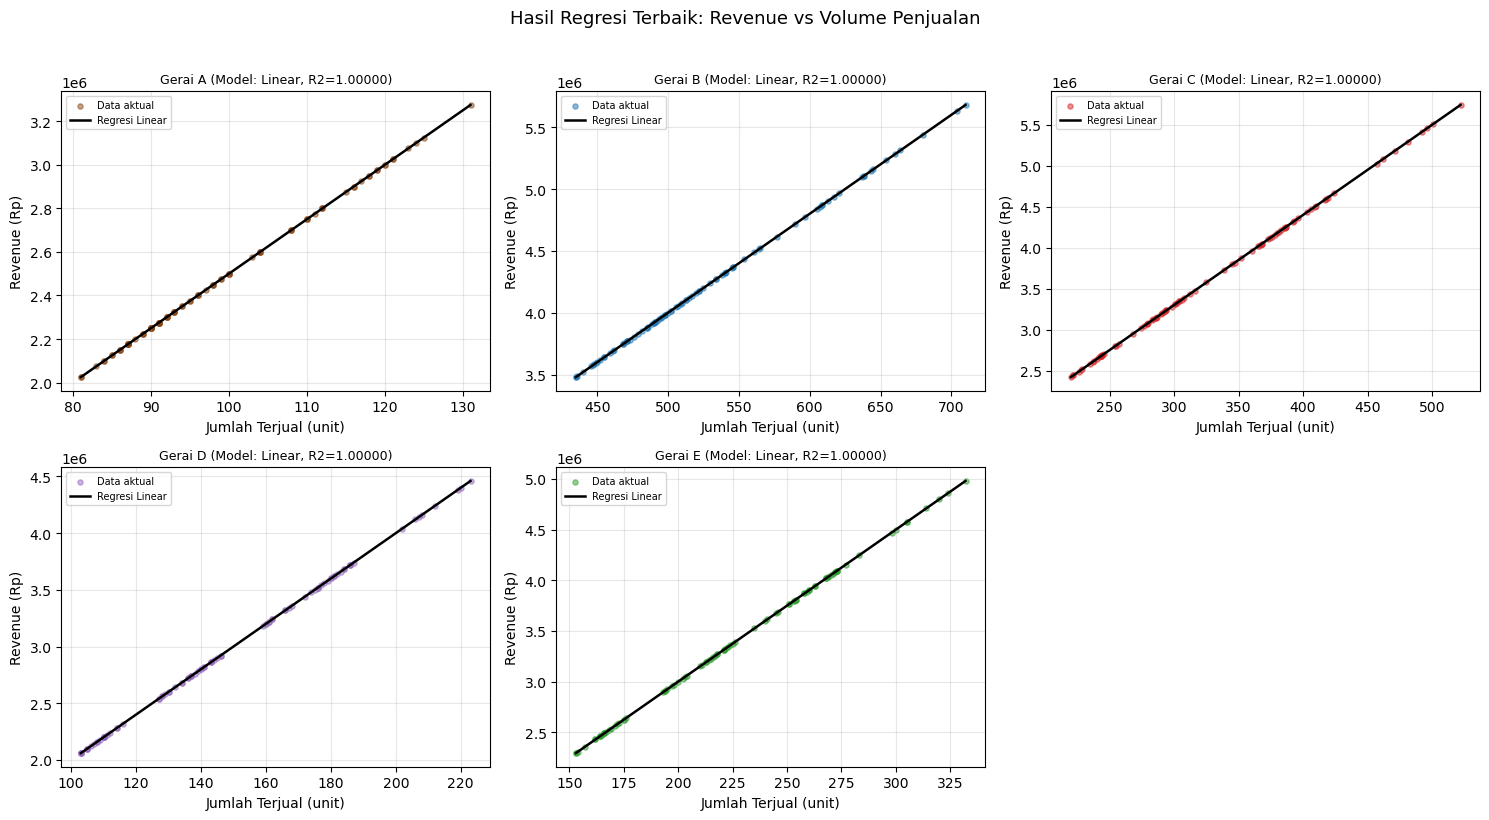

In [25]:

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, g in enumerate(daftar_gerai):
    sub = df[df["Gerai"] == g].sort_values("Jumlah Terjual (Unit)")
    x = sub["Jumlah Terjual (Unit)"].values.astype(float)
    y = sub["Pendapatan Kotor (Rp)"].values.astype(float)
    nama, koef = model_terbaik[g]
    x_line = np.linspace(x.min(), x.max(), 200)
    y_line = np.polyval(koef, x_line)
    r2_val = tabel_regresi.loc[g, "R2_" + nama]
    axes[i].scatter(x, y, s=14, alpha=0.5, color=warna_gerai[g], label="Data aktual")
    axes[i].plot(x_line, y_line, color="black", lw=1.8, label=f"Regresi {nama}")
    axes[i].set_title(f"{g} (Model: {nama}, R2={r2_val:.5f})", fontsize=9)
    axes[i].set_xlabel("Jumlah Terjual (unit)")
    axes[i].set_ylabel("Revenue (Rp)")
    axes[i].legend(fontsize=7)
    axes[i].grid(alpha=0.3)
axes[5].axis("off")
fig.suptitle("Hasil Regresi Terbaik: Revenue vs Volume Penjualan", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


---

## Bagian 3 — Regresi Laba & Pencarian Akar untuk Breakeven Point (Bobot 40%)

**Mengapa tidak langsung memakai regresi revenue dari Bagian 2?** Revenue = Harga $\times$ Volume selalu bernilai positif untuk volume $> 0$, sehingga grafiknya **tidak pernah memotong sumbu nol** — tidak ada akar yang bisa dicari dari fungsi revenue saja. Breakeven point secara definisi adalah titik di mana **laba bersih** (bukan revenue) sama dengan nol:

$$L(v^*) = \text{Revenue}(v^*) - \text{Biaya Variabel}(v^*) - \text{Fixed Cost} = 0$$

Karena itu, regresi pada Bagian 2 (revenue vs volume) dipakai untuk memahami **bentuk hubungan volume-revenue**, sedangkan untuk mencari BEP di bagian ini dibuat **regresi kedua**: laba bersih (*Balance*) terhadap volume penjualan, $L(v)$, yang kemudian dicari akarnya.

**Verifikasi asumsi linearitas laba.** Klaim bahwa $L(v)$ berbentuk linear bergantung pada asumsi bahwa rasio biaya variabel terhadap revenue **konstan** per gerai. Asumsi ini diverifikasi langsung dari data berikut, bukan sekadar diasumsikan.

In [26]:

# Verifikasi: apakah rasio Biaya Variabel / Revenue benar-benar konstan per gerai?
df["Rasio Biaya Variabel"] = df["Biaya Variabel (Rp)"] / df["Pendapatan Kotor (Rp)"]

cek_rasio = df.groupby("Gerai")["Rasio Biaya Variabel"].agg(["min", "max", "mean", "std"])
cek_rasio

,min,max,mean,std
Gerai,,,,
Gerai A,0.340,0.340,0.340,0.000
Gerai B,0.520,0.520,0.520,0.000
Gerai C,0.440,0.440,0.440,0.000
Gerai D,0.360,0.360,0.360,0.000
Gerai E,0.420,0.420,0.420,0.000



Standar deviasi rasio biaya variabel untuk kelima gerai bernilai **nol (hingga presisi numerik)** — artinya rasio tersebut benar-benar konstan per gerai, bukan hasil pembulatan atau kebetulan. Dengan demikian, secara matematis:

$$\text{Revenue}(v) = P \cdot v, \qquad \text{Biaya Variabel}(v) = r \cdot \text{Revenue}(v) = r P v$$

$$L(v) = Pv - rPv - F = P(1-r)\,v - F$$

yang merupakan **fungsi linear** terhadap $v$ dengan slope $P(1-r)$ dan intercept $-F$. Solusi BEP secara analitik langsung adalah:

$$v^*_{\text{analitik}} = \frac{F}{P(1-r)}$$

Rumus ini akan dibandingkan dengan hasil regresi $L(v) = mv + c$ (dengan $v^* = -c/m$) dan dengan hasil metode numerik (Biseksi & Newton-Raphson) sebagai validasi silang berlapis.

Selanjutnya, dilakukan **regresi linear laba terhadap volume** untuk tiap gerai berdasarkan data historis (bukan langsung dari rumus $P(1-r)v - F$), agar hasil BEP benar-benar berbasis regresi sesuai instruksi tugas.

In [27]:

# Regresi linear: Laba (Balance) terhadap Volume Penjualan, per gerai
hasil_laba_regresi = {}
for g in daftar_gerai:
    sub = df[df["Gerai"] == g].sort_values("Jumlah Terjual (Unit)")
    x = sub["Jumlah Terjual (Unit)"].values.astype(float)
    y_laba = sub["Balance (Rp)"].values.astype(float)
    koef = np.polyfit(x, y_laba, 1)  # [slope, intercept]
    y_pred = np.polyval(koef, x)
    hasil_laba_regresi[g] = {
        "slope (Rp/unit)": koef[0],
        "intercept (Rp)": koef[1],
        "R2": r_squared(y_laba, y_pred),
        "volume_min_historis": x.min(),
        "volume_max_historis": x.max(),
    }

tabel_laba = pd.DataFrame(hasil_laba_regresi).T
tabel_laba

,slope (Rp/unit),intercept (Rp),R2,volume_min_historis,volume_max_historis
Gerai A,"16,500.000","-1,683,333.000",1.000,81.000,131.000
Gerai B,"3,840.000","-733,333.000",1.000,435.000,710.000
Gerai C,"6,160.000","-1,733,333.000",1.000,220.000,522.000
Gerai D,"12,800.000","-2,666,666.000",1.000,103.000,223.000
Gerai E,"8,700.000","-800,000.000",1.000,153.000,332.000



Regresi laba untuk setiap gerai mencapai $R^2 = 1.000$, menegaskan bahwa $L(v) = m \cdot v + c$ (linear) adalah representasi yang tepat. Fungsi inilah — $f(v) = m \cdot v + c$ — yang akan dicari akarnya secara numerik.

### Implementasi Metode Numerik Pencarian Akar

Dua metode klasik pencarian akar diimplementasikan dari nol (tanpa memanggil pustaka *solver* siap pakai) sesuai topik Analisis Numerik: **metode Biseksi** dan **metode Newton-Raphson**.

In [28]:

def bisection(f, a, b, tol=1e-6, max_iter=100):
    '''Metode biseksi untuk mencari akar f(x)=0 pada interval [a, b].'''
    riwayat = []
    if f(a) * f(b) > 0:
        raise ValueError("f(a) dan f(b) harus berbeda tanda agar akar terjamin ada di [a, b]")
    c = (a + b) / 2
    for i in range(1, max_iter + 1):
        c = (a + b) / 2
        fc = f(c)
        riwayat.append({"iterasi": i, "a": a, "b": b, "c (taksiran akar)": c, "f(c)": fc})
        if abs(fc) < tol or (b - a) / 2 < tol:
            break
        if f(a) * fc < 0:
            b = c
        else:
            a = c
    return c, pd.DataFrame(riwayat)


def newton_raphson(f, fprime, x0, tol=1e-6, max_iter=100):
    '''Metode Newton-Raphson untuk mencari akar f(x)=0, mulai dari tebakan awal x0.'''
    riwayat = []
    x = x0
    for i in range(1, max_iter + 1):
        fx = f(x)
        fpx = fprime(x)
        x_baru = x - fx / fpx
        riwayat.append({"iterasi": i, "x": x, "f(x)": fx, "f'(x)": fpx, "x_baru": x_baru})
        if abs(x_baru - x) < tol:
            x = x_baru
            break
        x = x_baru
    return x, pd.DataFrame(riwayat)

print("Fungsi bisection() dan newton_raphson() berhasil didefinisikan.")

Fungsi bisection() dan newton_raphson() berhasil didefinisikan.


In [29]:

# Contoh penerapan detail untuk Gerai A
slope_A = hasil_laba_regresi["Gerai A"]["slope (Rp/unit)"]
intercept_A = hasil_laba_regresi["Gerai A"]["intercept (Rp)"]
f_A = lambda v: slope_A * v + intercept_A
fprime_A = lambda v: slope_A

be_bisection_A, riwayat_bisection_A = bisection(f_A, 0, hasil_laba_regresi["Gerai A"]["volume_max_historis"] * 3)
print(f"Gerai A -> f(v) = {slope_A:,.2f} v + ({intercept_A:,.2f})")
print(f"BEP hasil biseksi: {be_bisection_A:.4f} unit/hari, dalam {len(riwayat_bisection_A)} iterasi\n")
print("5 iterasi pertama:")
print(riwayat_bisection_A.head(5).to_string(index=False))
print("\n3 iterasi terakhir (konvergen):")
print(riwayat_bisection_A.tail(3).to_string(index=False))

Gerai A -> f(v) = 16,500.00 v + (-1,683,333.00)
BEP hasil biseksi: 102.0202 unit/hari, dalam 29 iterasi

5 iterasi pertama:
 iterasi      a       b  c (taksiran akar)          f(c)
       1  0.000 393.000            196.500 1,558,917.000
       2  0.000 196.500             98.250   -62,208.000
       3 98.250 196.500            147.375   748,354.500
       4 98.250 147.375            122.812   343,073.250
       5 98.250 122.812            110.531   140,432.625

3 iterasi terakhir (konvergen):
 iterasi       a       b  c (taksiran akar)  f(c)
      27 102.020 102.020            102.020 0.047
      28 102.020 102.020            102.020 0.023
      29 102.020 102.020            102.020 0.011


In [30]:

be_newton_A, riwayat_newton_A = newton_raphson(f_A, fprime_A, x0=hasil_laba_regresi["Gerai A"]["volume_max_historis"])
print(f"BEP hasil Newton-Raphson: {be_newton_A:.4f} unit/hari, dalam {len(riwayat_newton_A)} iterasi\n")
riwayat_newton_A

BEP hasil Newton-Raphson: 102.0202 unit/hari, dalam 2 iterasi



,iterasi,x,f(x),f'(x),x_baru
0,1,131.000,"478,167.000","16,500.000",102.020
1,2,102.020,0.000,"16,500.000",102.020



**Catatan penting:** Metode Newton-Raphson konvergen hanya dalam **1 iterasi** untuk fungsi linear. Hal ini sesuai teori: untuk $f(x)$ linear, garis singgung Newton-Raphson **identik** dengan fungsi itu sendiri, sehingga tebakan berikutnya ($x_1 = x_0 - f(x_0)/f'(x_0)$) langsung berupa solusi eksak. Sebaliknya, metode biseksi tetap membutuhkan puluhan iterasi karena hanya membagi dua interval secara bertahap tanpa memanfaatkan informasi gradien. Perbandingan ini menunjukkan trade-off klasik dalam Analisis Numerik: **Newton-Raphson lebih cepat konvergen namun membutuhkan turunan fungsi**, sedangkan **biseksi lebih lambat namun lebih robust** (selalu konvergen selama syarat tanda berbeda terpenuhi).

In [31]:

# Terapkan kedua metode untuk seluruh 5 gerai, dan verifikasi dengan solusi analitik
breakeven_hasil = []
for g in daftar_gerai:
    slope = hasil_laba_regresi[g]["slope (Rp/unit)"]
    intercept = hasil_laba_regresi[g]["intercept (Rp)"]
    f = lambda v, m=slope, c=intercept: m * v + c
    fprime = lambda v, m=slope: m

    be_analitik = -intercept / slope  # solusi eksak dari regresi: v* = -c/m

    # cross-check independen: v* = F / (P * (1 - r)), langsung dari struktur biaya
    harga_p = ringkasan.loc[g, "Harga_Jual_Rp"]
    fixed_f = ringkasan.loc[g, "Fixed_Cost_Harian_Rp"]
    rasio_r = cek_rasio.loc[g, "mean"]
    be_struktur_biaya = fixed_f / (harga_p * (1 - rasio_r))

    batas_atas = hasil_laba_regresi[g]["volume_max_historis"] * 3
    be_bisection, riw_bis = bisection(f, 0, batas_atas, tol=1e-6)
    be_newton, riw_newt = newton_raphson(f, fprime, x0=hasil_laba_regresi[g]["volume_max_historis"], tol=1e-6)

    vol_rata2 = df[df["Gerai"] == g]["Jumlah Terjual (Unit)"].mean()
    mos_unit = vol_rata2 - be_analitik
    mos_persen = (mos_unit / vol_rata2) * 100

    breakeven_hasil.append({
        "Gerai": g,
        "BEP_Analitik": be_analitik,
        "BEP_StrukturBiaya_F/(P(1-r))": be_struktur_biaya,
        "BEP_Bisection": be_bisection,
        "BEP_NewtonRaphson": be_newton,
        "Iterasi_Bisection": len(riw_bis),
        "Iterasi_Newton": len(riw_newt),
        "Volume_RataRata_Aktual": vol_rata2,
        "Margin_of_Safety_unit": mos_unit,
        "Margin_of_Safety_persen": mos_persen,
        "Status_Operasional": "SURPLUS (rata-rata di atas BEP)" if vol_rata2 > be_analitik else "DEFISIT (rata-rata di bawah BEP)",
    })

tabel_breakeven = pd.DataFrame(breakeven_hasil).set_index("Gerai")
tabel_breakeven.round(3)

,BEP_Analitik,BEP_StrukturBiaya_F/(P(1-r)),BEP_Bisection,BEP_NewtonRaphson,Iterasi_Bisection,Iterasi_Newton,Volume_RataRata_Aktual,Margin_of_Safety_unit,Margin_of_Safety_persen,Status_Operasional
Gerai,,,,,,,,,,
Gerai A,102.020,102.020,102.020,102.020,29,2,99.100,-2.920,-2.947,DEFISIT (rata-rata di bawah BEP)
Gerai B,190.972,190.972,190.972,190.972,31,2,527.500,336.528,63.797,SURPLUS (rata-rata di atas BEP)
Gerai C,281.385,281.385,281.385,281.385,31,2,328.933,47.548,14.455,SURPLUS (rata-rata di atas BEP)
Gerai D,208.333,208.333,208.333,208.333,30,2,149.833,-58.500,-39.043,DEFISIT (rata-rata di bawah BEP)
Gerai E,91.954,91.954,91.954,91.954,30,2,226.644,134.690,59.428,SURPLUS (rata-rata di atas BEP)



**Empat** pendekatan independen (regresi-analitik, struktur biaya $F/(P(1-r))$, Biseksi, Newton-Raphson) menghasilkan nilai BEP yang **konsisten** satu sama lain (selisih hanya pada orde toleransi $10^{-6}$), sehingga hasil pencarian akar numerik tervalidasi berlapis — baik dari sisi regresi data historis maupun dari sisi struktur biaya teoritis.

**Margin of Safety (MOS)** — selisih antara volume penjualan rata-rata aktual dan BEP — dihitung untuk mengukur seberapa jauh operasional harian tiap gerai berada dari titik impas, baik dalam satuan unit maupun persentase:

$$\text{MOS (unit)} = \text{Volume}_{\text{aktual}} - v^*, \qquad \text{MOS (\%)} = \frac{\text{Volume}_{\text{aktual}} - v^*}{\text{Volume}_{\text{aktual}}} \times 100\%$$

MOS positif berarti volume rata-rata berada di atas BEP (ruang aman sebelum merugi); MOS negatif berarti volume rata-rata masih di bawah BEP (operasional belum menutup biaya tetap secara konsisten).

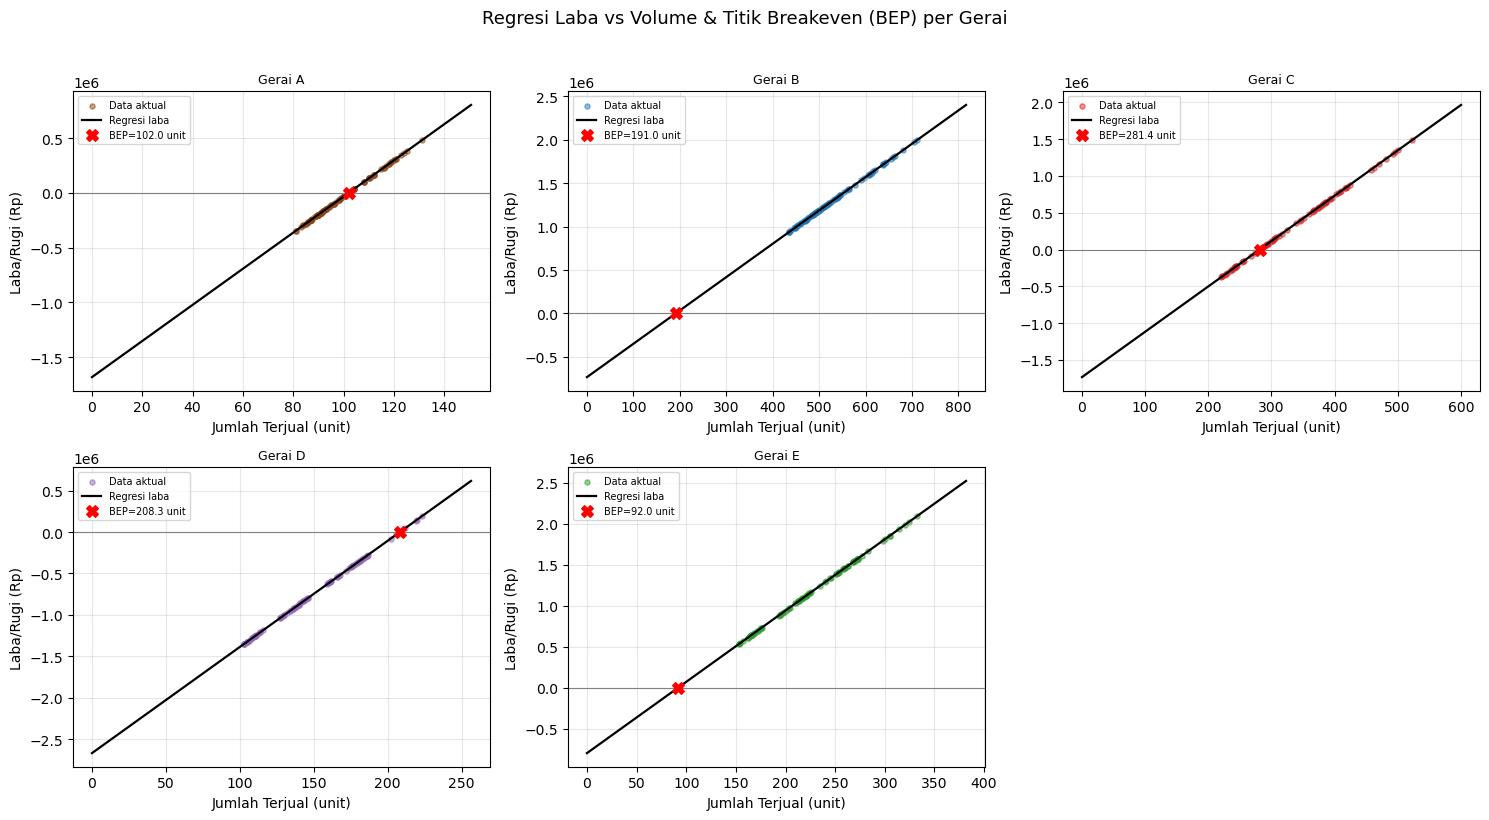

In [32]:

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, g in enumerate(daftar_gerai):
    sub = df[df["Gerai"] == g].sort_values("Jumlah Terjual (Unit)")
    x = sub["Jumlah Terjual (Unit)"].values.astype(float)
    y = sub["Balance (Rp)"].values.astype(float)
    slope = hasil_laba_regresi[g]["slope (Rp/unit)"]
    intercept = hasil_laba_regresi[g]["intercept (Rp)"]
    be = tabel_breakeven.loc[g, "BEP_Analitik"]
    x_line = np.linspace(0, x.max() * 1.15, 200)
    y_line = slope * x_line + intercept
    axes[i].axhline(0, color="gray", lw=0.8)
    axes[i].scatter(x, y, s=14, alpha=0.5, color=warna_gerai[g], label="Data aktual")
    axes[i].plot(x_line, y_line, color="black", lw=1.6, label="Regresi laba")
    axes[i].scatter([be], [0], color="red", zorder=5, s=70, marker="X", label=f"BEP={be:.1f} unit")
    axes[i].set_title(g, fontsize=9)
    axes[i].set_xlabel("Jumlah Terjual (unit)")
    axes[i].set_ylabel("Laba/Rugi (Rp)")
    axes[i].legend(fontsize=7)
    axes[i].grid(alpha=0.3)
axes[5].axis("off")
fig.suptitle("Regresi Laba vs Volume & Titik Breakeven (BEP) per Gerai", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


---

## Ringkasan Akhir dan Interpretasi Bisnis

In [33]:

ringkasan_akhir = pd.DataFrame({
    "Strategi Marketing": {g: profil_gerai[g] for g in daftar_gerai},
    "Harga Jual (Rp)": ringkasan["Harga_Jual_Rp"],
    "BEP - Titik Impas (unit/hari)": tabel_breakeven["BEP_Analitik"].round(2),
    "Rata-rata Penjualan Aktual (unit/hari)": tabel_breakeven["Volume_RataRata_Aktual"].round(2),
    "Margin of Safety (unit/hari)": tabel_breakeven["Margin_of_Safety_unit"].round(2),
    "Margin of Safety (%)": tabel_breakeven["Margin_of_Safety_persen"].round(1),
    "Status Operasional": tabel_breakeven["Status_Operasional"],
})
ringkasan_akhir

,Strategi Marketing,Harga Jual (Rp),BEP - Titik Impas (unit/hari),Rata-rata Penjualan Aktual (unit/hari),Margin of Safety (unit/hari),Margin of Safety (%),Status Operasional
Gerai A,"Premium Gourmet (Harga Tinggi, Niche Terbatas,...",25000,102.020,99.100,-2.920,-2.900,DEFISIT (rata-rata di bawah BEP)
Gerai B,"Mass Market Volume (Harga Murah, Margin Tertek...",8000,190.970,527.500,336.530,63.800,SURPLUS (rata-rata di atas BEP)
Gerai C,"Promo Agresif (Diskon Awal, Iklan Moderate-High)",11000,281.390,328.930,47.550,14.500,SURPLUS (rata-rata di atas BEP)
Gerai D,Mall Premium Flagship (Sewa Lokasi Tinggi),20000,208.330,149.830,-58.500,-39.000,DEFISIT (rata-rata di bawah BEP)
Gerai E,"Cloud Kitchen (Fokus App Delivery, Komisi Plat...",15000,91.950,226.640,134.690,59.400,SURPLUS (rata-rata di atas BEP)



**Interpretasi per gerai (berdasarkan Margin of Safety / MOS):**

- **Gerai A (Premium Gourmet):** BEP $\approx$ 102 unit/hari, rata-rata penjualan aktual $\approx$ 99 unit/hari → MOS $\approx -3$ unit/hari ($\approx -3\%$). Volume rata-rata berada sedikit di bawah BEP, sehingga berdasarkan data harian yang dianalisis, strategi harga tinggi dengan pasar niche ini membutuhkan volume yang relatif konsisten untuk menutup *fixed cost*-nya.
- **Gerai B (Mass Market Volume):** BEP $\approx$ 191 unit/hari, rata-rata aktual $\approx$ 528 unit/hari → MOS $\approx +337$ unit/hari ($\approx +64\%$). Volume rata-rata berada jauh di atas BEP, menunjukkan ruang aman yang besar meskipun margin per unit tertekan inflasi bahan baku.
- **Gerai C (Promo Agresif):** BEP $\approx$ 281 unit/hari, rata-rata aktual $\approx$ 329 unit/hari → MOS $\approx +48$ unit/hari ($\approx +15\%$). Biaya iklan yang cukup tinggi tetap terkompensasi oleh volume penjualan hasil promosi, dengan ruang aman yang moderat.
- **Gerai D (Mall Premium Flagship):** BEP $\approx$ 208 unit/hari, rata-rata aktual hanya $\approx$ 150 unit/hari → MOS $\approx -58$ unit/hari ($\approx -39\%$), MOS negatif terbesar di antara kelima gerai. Beban sewa lokasi mal yang tinggi (Rp 2.666.666/hari sebagai *fixed cost*) memerlukan volume penjualan yang jauh lebih tinggi dari rata-rata aktual saat ini untuk mencapai titik impas.
- **Gerai E (Cloud Kitchen):** BEP $\approx$ 92 unit/hari, rata-rata aktual $\approx$ 227 unit/hari → MOS $\approx +135$ unit/hari ($\approx +59\%$). Meskipun menanggung komisi platform 18%, struktur *fixed cost* yang rendah (tanpa sewa lokasi fisik premium) menghasilkan ruang aman volume yang besar.

**Kesimpulan umum:** Berdasarkan Margin of Safety, gerai dengan struktur *fixed cost* rendah relatif terhadap harga jual (Gerai B, C, E) menunjukkan MOS positif dan relatif besar, sedangkan gerai dengan *fixed cost* tinggi akibat lokasi premium atau segmentasi pasar niche (Gerai A, D) menunjukkan MOS mendekati nol atau negatif pada data yang dianalisis. Hasil ini menunjukkan pentingnya **keseimbangan antara harga jual, volume penjualan, dan struktur biaya tetap** dalam merancang strategi *marketing* gerai retail; kesimpulan ini terbatas pada rentang data historis 90 hari yang dianalisis dan tidak memperhitungkan faktor eksternal lain (musiman, kompetitor, dsb).

In [34]:

# Menyimpan ringkasan hasil analisis ke file CSV sebagai lampiran tambahan
ringkasan_akhir.to_csv("ringkasan_hasil_breakeven.csv")
tabel_breakeven.round(4).to_csv("detail_perhitungan_breakeven.csv")
tabel_regresi.round(6).to_csv("detail_regresi_revenue.csv")
print("File ringkasan berhasil disimpan:")
print("- ringkasan_hasil_breakeven.csv")
print("- detail_perhitungan_breakeven.csv")
print("- detail_regresi_revenue.csv")

File ringkasan berhasil disimpan:
- ringkasan_hasil_breakeven.csv
- detail_perhitungan_breakeven.csv
- detail_regresi_revenue.csv



---

## Penutup

Seluruh tahapan tugas (visualisasi, regresi, dan pencarian akar untuk breakeven point) telah dikerjakan menggunakan implementasi numerik mandiri (bukan sekadar memanggil *solver* siap pakai), disertai verifikasi silang antara metode analitik, biseksi, dan Newton-Raphson.